In [2]:
# 1. ?????


import os
import copy
import numpy as np
import pandas as pd
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

In [3]:
import torch
print(torch.cuda.get_device_name(0))

NVIDIA GeForce RTX 4060


In [5]:
# 2. 4~8월 cargo CSV 로딩

file_paths = [
    r"C:\Users\HP\Desktop\prE\04cargo.csv",
    r"C:\Users\HP\Desktop\prE\05cargo.csv",
    r"C:\Users\HP\Desktop\prE\06cargo.csv",
    r"C:\Users\HP\Desktop\prE\07cargo.csv",
    r"C:\Users\HP\Desktop\prE\08cargo.csv",
]

df_list = []

for path in file_paths:
    temp = pd.read_csv(path)
    temp["source_file"] = os.path.basename(path)
    df_list.append(temp)

df_raw = pd.concat(df_list, ignore_index=True)

print(df_raw.shape)
print(df_raw.columns)
df_raw.head()

(4500839, 20)
Index(['MMSI', 'Date', 'Lat', 'Long', 'SOG', 'COG', 'Heading', 'Name', 'Type',
       'IMO', 'Call', 'DimA', 'DimB', 'DimC', 'DimD', 'Draft', 'Tons',
       'Length', 'Breadth', 'source_file'],
      dtype='str')


,MMSI,Date,Lat,Long,SOG,COG,Heading,Name,Type,IMO,Call,DimA,DimB,DimC,DimD,Draft,Tons,Length,Breadth,source_file
0,215331000,2024-04-01 00:02:56,35.067482,128.808068,0.0,285.7,78,CMA CGM ARGENTINA,70.0,9839909.0,9HA5066,110.0,256.0,29.0,22.0,14.4,169408.0,366.0,51.0,04cargo.csv
1,215331000,2024-04-01 00:05:56,35.067487,128.808107,0.0,233.2,78,CMA CGM ARGENTINA,70.0,9839909.0,9HA5066,110.0,256.0,29.0,22.0,14.4,169408.0,366.0,51.0,04cargo.csv
2,215331000,2024-04-01 00:08:56,35.067478,128.808130,0.0,236.5,78,CMA CGM ARGENTINA,70.0,9839909.0,9HA5066,110.0,256.0,29.0,22.0,14.4,169408.0,366.0,51.0,04cargo.csv
3,215331000,2024-04-01 00:11:56,35.067490,128.808120,0.0,242.4,78,CMA CGM ARGENTINA,70.0,9839909.0,9HA5066,110.0,256.0,29.0,22.0,14.4,169408.0,366.0,51.0,04cargo.csv
4,215331000,2024-04-01 00:14:56,35.067518,128.808348,0.0,238.9,78,CMA CGM ARGENTINA,70.0,9839909.0,9HA5066,110.0,256.0,29.0,22.0,14.4,169408.0,366.0,51.0,04cargo.csv


In [6]:
# 3. 컬럼 정리 및 기본 전처리

df = df_raw[["MMSI", "Date", "Lat", "Long", "SOG", "COG", "Heading", "source_file"]].copy()

df = df.rename(columns={
    "Date": "timestamp",
    "Lat": "lat",
    "Long": "lon",
    "SOG": "sog",
    "COG": "cog",
    "Heading": "heading"
})

df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

for col in ["lat", "lon", "sog", "cog", "heading"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["MMSI", "timestamp", "lat", "lon", "sog", "cog", "heading"])

df = df[
    (df["lat"].between(-90, 90)) &
    (df["lon"].between(-180, 180)) &
    (df["sog"] >= 0) &
    (df["cog"].between(0, 360)) &
    (df["heading"].between(0, 360))
].copy()

df = df.sort_values(["MMSI", "timestamp"]).reset_index(drop=True)

df["month"] = df["timestamp"].dt.month

print(df.shape)
print(df["month"].value_counts().sort_index())
df.head()

(4417967, 9)
month
4    826933
5    900471
6    907346
7    912136
8    871081
Name: count, dtype: int64


,MMSI,timestamp,lat,lon,sog,cog,heading,source_file,month
0,209079000,2024-08-05 03:42:22,34.960100,128.823167,9.9,339.7,338,08cargo.csv,8
1,209079000,2024-08-05 03:42:32,34.960518,128.822972,9.8,339.7,338,08cargo.csv,8
2,209079000,2024-08-05 03:42:42,34.960935,128.822775,9.6,339.1,338,08cargo.csv,8
3,209079000,2024-08-05 03:42:52,34.961335,128.822592,9.4,338.6,338,08cargo.csv,8
4,209079000,2024-08-05 03:43:02,34.961732,128.822387,9.3,338.0,338,08cargo.csv,8


In [7]:
# 4. 이동 선박 / 정지 선박 기준

MOVING_THRESHOLD = 0.5

moving_df = df[df["sog"] > MOVING_THRESHOLD].copy()
stationary_df = df[df["sog"] <= MOVING_THRESHOLD].copy()

print("전체 데이터:", len(df))
print("이동 선박 데이터:", len(moving_df))
print("정지/저속 선박 데이터:", len(stationary_df))

전체 데이터: 4417967
이동 선박 데이터: 2614784
정지/저속 선박 데이터: 1803183


In [8]:
# 5. Grid 설정
# Interaction Graph 학습용: 0.5 NM
# 최종 혼잡도 시각화용: 1.0 NM

TRAIN_GRID_NM = 0.1
VIS_GRID_NM = 0.1

BASE_LAT_FOR_LON_SCALE = 35.0

TRAIN_LAT_GRID_SIZE = (TRAIN_GRID_NM * 1.852) / 111
TRAIN_LON_GRID_SIZE = (TRAIN_GRID_NM * 1.852) / (
    111 * np.cos(np.radians(BASE_LAT_FOR_LON_SCALE))
)

VIS_LAT_GRID_SIZE = (VIS_GRID_NM * 1.852) / 111
VIS_LON_GRID_SIZE = (VIS_GRID_NM * 1.852) / (
    111 * np.cos(np.radians(BASE_LAT_FOR_LON_SCALE))
)

print("TRAIN_LAT_GRID_SIZE:", TRAIN_LAT_GRID_SIZE)
print("TRAIN_LON_GRID_SIZE:", TRAIN_LON_GRID_SIZE)
print("VIS_LAT_GRID_SIZE:", VIS_LAT_GRID_SIZE)
print("VIS_LON_GRID_SIZE:", VIS_LON_GRID_SIZE)

TRAIN_LAT_GRID_SIZE: 0.0016684684684684687
TRAIN_LON_GRID_SIZE: 0.0020368239084560514
VIS_LAT_GRID_SIZE: 0.0016684684684684687
VIS_LON_GRID_SIZE: 0.0020368239084560514


In [9]:
# 6. AIS ??? 5? ?? resampling ??
# ?? ??(COG/Heading)? ?? ??? ????.

RESAMPLE_INTERVAL = "5min"


def circular_mean_deg(series):
    values = series.dropna().values

    if len(values) == 0:
        return np.nan

    radians = np.radians(values)
    sin_mean = np.mean(np.sin(radians))
    cos_mean = np.mean(np.cos(radians))

    angle = np.degrees(np.arctan2(sin_mean, cos_mean))
    return angle + 360 if angle < 0 else angle


def resample_ais_5min(df):
    result = []

    for mmsi, group in df.groupby("MMSI"):
        group = group.sort_values("timestamp").set_index("timestamp")

        resampled = group[["lat", "lon", "sog"]].resample(RESAMPLE_INTERVAL).mean()
        resampled["cog"] = group["cog"].resample(RESAMPLE_INTERVAL).apply(circular_mean_deg)
        resampled["heading"] = group["heading"].resample(RESAMPLE_INTERVAL).apply(circular_mean_deg)

        resampled = resampled.interpolate(method="linear").dropna()
        resampled["MMSI"] = mmsi
        result.append(resampled.reset_index())

    if len(result) == 0:
        return pd.DataFrame(columns=["timestamp", "lat", "lon", "sog", "cog", "heading", "MMSI"])

    return pd.concat(result, ignore_index=True)

In [10]:
# 7. ? ?? Train / Validation / Test ?? ? resampling
# ?? ??? ?? ???? ? ???? ?? ??? ?? ? ???? split ? resampling??.

train_month_raw = moving_df[moving_df["month"].isin([4, 5, 6])].copy()
val_month_raw = moving_df[moving_df["month"].isin([7])].copy()
test_month_raw = moving_df[moving_df["month"].isin([8])].copy()

train_raw = resample_ais_5min(train_month_raw)
val_raw = resample_ais_5min(val_month_raw)
test_raw = resample_ais_5min(test_month_raw)

for split_df in [train_raw, val_raw, test_raw]:
    split_df["month"] = split_df["timestamp"].dt.month

moving_resampled = pd.concat([train_raw, val_raw, test_raw], ignore_index=True)
moving_resampled = moving_resampled.sort_values(["MMSI", "timestamp"]).reset_index(drop=True)

print("train_raw:", train_raw.shape)
print("val_raw:", val_raw.shape)
print("test_raw:", test_raw.shape)
print("all moving_resampled:", moving_resampled.shape)

train_raw: (6171963, 8)
val_raw: (730793, 8)
test_raw: (725290, 8)
all moving_resampled: (7628046, 8)


In [11]:
# 8. ???
# scaler? train_raw?? fit?? val/test/all?? transform? ????.

feature_cols = ["lat", "lon", "sog", "cog", "heading"]
target_cols = ["lat", "lon"]

x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

x_scaler.fit(train_raw[feature_cols])
y_scaler.fit(train_raw[target_cols])


def apply_scaling(raw_df):
    norm_df = raw_df.copy()
    norm_df[feature_cols] = x_scaler.transform(raw_df[feature_cols])
    norm_df[target_cols] = y_scaler.transform(raw_df[target_cols])
    return norm_df


train_norm = apply_scaling(train_raw)
val_norm = apply_scaling(val_raw)
test_norm = apply_scaling(test_raw)
all_norm = apply_scaling(moving_resampled)

train_norm.head()

,timestamp,lat,lon,sog,cog,heading,MMSI,month
0,2024-04-15 10:35:00,0.002318,0.898242,0.095379,0.940278,0.944444,209423000,4
1,2024-04-15 10:40:00,0.058490,0.844810,0.093379,0.941954,0.944444,209423000,4
2,2024-04-15 10:45:00,0.160297,0.750063,0.081613,0.942333,0.944444,209423000,4
3,2024-04-15 10:50:00,0.252004,0.664034,0.076696,0.942269,0.944444,209423000,4
4,2024-04-15 10:55:00,0.346525,0.578389,0.086988,0.943074,0.944444,209423000,4


In [12]:
# 9. Interaction transition statistics ??
# train_raw?? grid ? ?? ??? ????.
# ?? sequence? interaction adjacency matrix? 10??? ? ??? ??? ???.


def latlon_to_grid(lat, lon, lat_min, lon_min, lat_grid_size, lon_grid_size):
    row = int((lat - lat_min) / lat_grid_size)
    col = int((lon - lon_min) / lon_grid_size)
    return row, col


def build_interaction_counts(df):
    transition_counts = defaultdict(int)

    lat_min = df["lat"].min()
    lon_min = df["lon"].min()

    for mmsi, group in df.groupby("MMSI"):
        group = group.sort_values("timestamp")
        coords = group[["lat", "lon"]].values

        for i in range(len(coords) - 1):
            g1 = latlon_to_grid(
                coords[i][0], coords[i][1],
                lat_min, lon_min,
                TRAIN_LAT_GRID_SIZE, TRAIN_LON_GRID_SIZE
            )
            g2 = latlon_to_grid(
                coords[i + 1][0], coords[i + 1][1],
                lat_min, lon_min,
                TRAIN_LAT_GRID_SIZE, TRAIN_LON_GRID_SIZE
            )
            transition_counts[(g1, g2)] += 1

    return transition_counts, lat_min, lon_min


transition_counts, train_lat_min, train_lon_min = build_interaction_counts(train_raw)

print("interaction transition count:", len(transition_counts))
print("train_lat_min:", train_lat_min)
print("train_lon_min:", train_lon_min)

interaction transition count: 13537
train_lat_min: 34.96
train_lon_min: 128.770005


In [13]:
# 10. Sequence? Multi-Graph ?? ??
# Distance graph? sequence? ??? ?? ????,
# Interaction graph? 9??? ?? train ?? transition statistics? ????.


def create_distance_graph(raw_seq, sigma_km=1.0):
    coords = raw_seq[:, :2]

    lat_km = coords[:, 0] * 111.0
    lon_km = coords[:, 1] * 111.0 * np.cos(np.radians(BASE_LAT_FOR_LON_SCALE))
    xy = np.stack([lat_km, lon_km], axis=1)

    diff = xy[:, None, :] - xy[None, :, :]
    dist_km = np.sqrt(np.sum(diff ** 2, axis=-1))

    A = np.exp(-dist_km / sigma_km)
    return A.astype(np.float32)


def create_interaction_graph(raw_seq):
    N = len(raw_seq)
    A = np.zeros((N, N), dtype=np.float32)

    nodes = [
        latlon_to_grid(
            lat, lon,
            train_lat_min, train_lon_min,
            TRAIN_LAT_GRID_SIZE, TRAIN_LON_GRID_SIZE
        )
        for lat, lon, sog, cog, heading in raw_seq
    ]

    for i in range(N):
        for j in range(N):
            A[i, j] = transition_counts.get((nodes[i], nodes[j]), 0)

    if A.max() > 0:
        A = A / (A.max() + 1e-6)

    return A.astype(np.float32)


def create_multi_graph(raw_seq):
    A_distance = create_distance_graph(raw_seq)
    A_interaction = create_interaction_graph(raw_seq)
    return np.stack([A_distance, A_interaction], axis=0).astype(np.float32)

In [14]:
# 11. ?? 10? ???? ?? 5? ?? ?? sequence ??


def create_next_step_sequences_with_graph(raw_df, norm_df, seq_len=10, stride=3, max_sequences=None):
    sequences = []

    for mmsi in raw_df["MMSI"].unique():
        raw_group = raw_df[raw_df["MMSI"] == mmsi].sort_values("timestamp").reset_index(drop=True)
        norm_group = norm_df[norm_df["MMSI"] == mmsi].sort_values("timestamp").reset_index(drop=True)

        if len(raw_group) <= seq_len:
            continue

        raw_data = raw_group[feature_cols].values.astype(np.float32)
        norm_data = norm_group[feature_cols].values.astype(np.float32)

        for i in range(0, len(raw_group) - seq_len, stride):
            raw_seq = raw_data[i:i + seq_len]
            norm_seq = norm_data[i:i + seq_len]
            target = norm_data[i + seq_len][:2]
            graph = create_multi_graph(raw_seq)

            sequences.append((norm_seq, graph, target))

            if max_sequences is not None and len(sequences) >= max_sequences:
                return sequences

    return sequences


SEQ_LEN = 10
TRAIN_STRIDE = 3
VAL_STRIDE = 5
TEST_STRIDE = 5

MAX_TRAIN_SEQUENCES = 200000
MAX_VAL_SEQUENCES = 50000
MAX_TEST_SEQUENCES = 50000

train_sequences = create_next_step_sequences_with_graph(
    train_raw, train_norm, seq_len=SEQ_LEN, stride=TRAIN_STRIDE, max_sequences=MAX_TRAIN_SEQUENCES
)
val_sequences = create_next_step_sequences_with_graph(
    val_raw, val_norm, seq_len=SEQ_LEN, stride=VAL_STRIDE, max_sequences=MAX_VAL_SEQUENCES
)
test_sequences = create_next_step_sequences_with_graph(
    test_raw, test_norm, seq_len=SEQ_LEN, stride=TEST_STRIDE, max_sequences=MAX_TEST_SEQUENCES
)

print("train_sequences:", len(train_sequences))
print("val_sequences:", len(val_sequences))
print("test_sequences:", len(test_sequences))
print("sample norm_seq:", train_sequences[0][0].shape)
print("sample graph:", train_sequences[0][1].shape)
print("sample target:", train_sequences[0][2].shape)

train_sequences: 200000
val_sequences: 50000
test_sequences: 50000
sample norm_seq: (10, 5)
sample graph: (2, 10, 10)
sample target: (2,)


In [15]:
# 12. Dataset / DataLoader
# graph는 이미 pre-compute 되어 있음

class AISDataset(Dataset):
    def __init__(self, sequences):
        self.sequences = sequences

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        norm_seq, graph, target = self.sequences[idx]

        return (
            torch.tensor(norm_seq, dtype=torch.float32),
            torch.tensor(graph, dtype=torch.float32),
            torch.tensor(target, dtype=torch.float32)
        )


BATCH_SIZE = 32

train_dataset = AISDataset(train_sequences)
val_dataset = AISDataset(val_sequences)
test_dataset = AISDataset(test_sequences)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

for X, graphs, y in train_loader:
    print("X:", X.shape)
    print("graphs:", graphs.shape)
    print("y:", y.shape)
    break

X: torch.Size([32, 10, 5])
graphs: torch.Size([32, 2, 10, 10])
y: torch.Size([32, 2])


In [16]:
# 13. STMGCN ?? ??
# Spatial-Temporal Multi-Graph Convolutional Network

class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.1):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(out_dim)

    def forward(self, X, A):
        B, T, _ = X.shape

        I = torch.eye(T, device=X.device, dtype=X.dtype).unsqueeze(0).expand(B, T, T)
        A_hat = A.to(dtype=X.dtype) + I

        degree = torch.sum(A_hat, dim=-1).clamp_min(1e-6)
        degree_inv_sqrt = torch.pow(degree, -0.5)
        A_norm = degree_inv_sqrt.unsqueeze(-1) * A_hat * degree_inv_sqrt.unsqueeze(-2)

        H = A_norm @ self.linear(X)
        H = F.relu(H)
        H = self.dropout(H)

        return self.norm(H)


class MultiGraphAttentionFusion(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.score_layer = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.Tanh(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, H_list):
        scores = []

        for H in H_list:
            graph_score = self.score_layer(H).mean(dim=1)
            scores.append(graph_score)

        scores = torch.cat(scores, dim=1)
        weights = F.softmax(scores, dim=1)

        fused = torch.zeros_like(H_list[0])
        for i, H in enumerate(H_list):
            w = weights[:, i].view(-1, 1, 1)
            fused = fused + w * H

        return fused, weights


class TemporalConvBlock(nn.Module):
    def __init__(self, hidden_dim, kernel_size=3, dropout=0.1):
        super().__init__()
        padding = kernel_size // 2

        self.filter_conv = nn.Conv1d(hidden_dim, hidden_dim, kernel_size, padding=padding)
        self.gate_conv = nn.Conv1d(hidden_dim, hidden_dim, kernel_size, padding=padding)
        self.proj = nn.Conv1d(hidden_dim, hidden_dim, kernel_size=1)
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(hidden_dim)

    def forward(self, x):
        residual = x

        x = x.transpose(1, 2)
        z = torch.tanh(self.filter_conv(x))
        g = torch.sigmoid(self.gate_conv(x))
        x = self.proj(z * g)
        x = self.dropout(x)
        x = x.transpose(1, 2)

        return self.norm(x + residual)


class STMGCN(nn.Module):
    def __init__(
        self,
        input_dim=5,
        hidden_dim=64,
        num_graphs=2,
        output_dim=2,
        num_temporal_blocks=2,
        dropout=0.1
    ):
        super().__init__()

        self.num_graphs = num_graphs

        self.input_projection = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim)
        )

        self.gcn_layers = nn.ModuleList([
            GCNLayer(hidden_dim, hidden_dim, dropout=dropout)
            for _ in range(num_graphs)
        ])

        self.graph_fusion = MultiGraphAttentionFusion(hidden_dim)

        self.temporal_blocks = nn.ModuleList([
            TemporalConvBlock(hidden_dim, dropout=dropout)
            for _ in range(num_temporal_blocks)
        ])

        self.output_layer = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, output_dim)
        )

        self.last_graph_weights = None

    def forward(self, X, graphs):
        H0 = self.input_projection(X)

        H_list = []
        for i in range(self.num_graphs):
            A = graphs[:, i, :, :]
            H = self.gcn_layers[i](H0, A)
            H_list.append(H)

        H, graph_weights = self.graph_fusion(H_list)
        self.last_graph_weights = graph_weights.detach()

        for block in self.temporal_blocks:
            H = block(H)

        last_hidden = H[:, -1, :]
        return self.output_layer(last_hidden)

In [17]:
# 14. ?? ??

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

model = STMGCN(
    input_dim=5,
    hidden_dim=64,
    num_graphs=2,
    output_dim=2,
    num_temporal_blocks=2,
    dropout=0.1
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
criterion = nn.MSELoss()

device: cuda


In [27]:
# 15. ?? ?? + Validation ?? + Early Stopping


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for X, graphs, y in loader:
        X = X.to(device)
        graphs = graphs.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        pred = model(X, graphs)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate_loss(model, loader, criterion):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for X, graphs, y in loader:
            X = X.to(device)
            graphs = graphs.to(device)
            y = y.to(device)

            pred = model(X, graphs)
            loss = criterion(pred, y)
            total_loss += loss.item()

    return total_loss / len(loader)


EPOCHS = 2000
PATIENCE = 150

best_val_loss = float("inf")
patience_counter = 0
best_model_state = None

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss = evaluate_loss(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch + 1}/{EPOCHS}] Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print("Early stopping")
        break

if best_model_state is not None:
    model.load_state_dict(best_model_state)

print("Best Val Loss:", best_val_loss)

Epoch [1/2000] Train Loss: 0.000670 | Val Loss: 0.000587
Epoch [2/2000] Train Loss: 0.000626 | Val Loss: 0.000879
Epoch [3/2000] Train Loss: 0.000599 | Val Loss: 0.000915
Epoch [4/2000] Train Loss: 0.000586 | Val Loss: 0.000538
Epoch [5/2000] Train Loss: 0.000581 | Val Loss: 0.001364
Epoch [6/2000] Train Loss: 0.000584 | Val Loss: 0.000532
Epoch [7/2000] Train Loss: 0.000572 | Val Loss: 0.001411
Epoch [8/2000] Train Loss: 0.000574 | Val Loss: 0.000850
Epoch [9/2000] Train Loss: 0.000560 | Val Loss: 0.000757
Epoch [10/2000] Train Loss: 0.000568 | Val Loss: 0.000705
Epoch [11/2000] Train Loss: 0.000567 | Val Loss: 0.000484
Epoch [12/2000] Train Loss: 0.000558 | Val Loss: 0.001157
Epoch [13/2000] Train Loss: 0.000558 | Val Loss: 0.001372
Epoch [14/2000] Train Loss: 0.000554 | Val Loss: 0.001179
Epoch [15/2000] Train Loss: 0.000557 | Val Loss: 0.001573
Epoch [16/2000] Train Loss: 0.000549 | Val Loss: 0.001926
Epoch [17/2000] Train Loss: 0.000555 | Val Loss: 0.001797
Epoch [18/2000] Train L

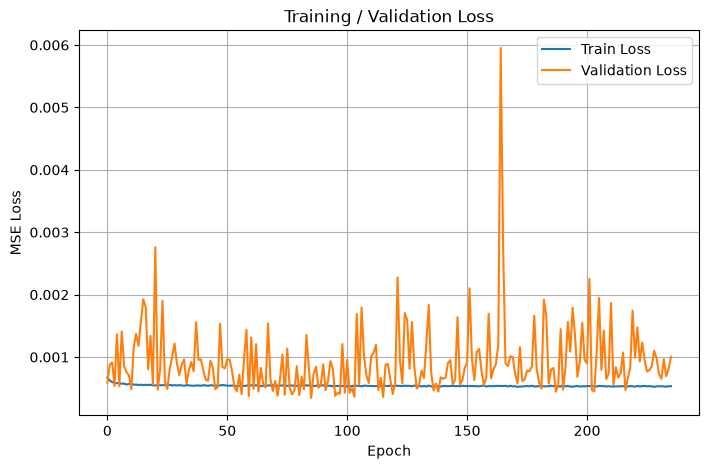

In [28]:
# 16. 학습 곡선 확인

plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training / Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [29]:
# 17. Test set 다음 5분 위치 예측 확인

model.eval()

with torch.no_grad():
    for X, graphs, y in test_loader:
        X = X.to(device)
        graphs = graphs.to(device)
        y = y.to(device)

        pred = model(X, graphs)

        pred_original = y_scaler.inverse_transform(pred.cpu().numpy())
        true_original = y_scaler.inverse_transform(y.cpu().numpy())

        print("예측값 Lat/Lon:")
        print(pred_original[:5])

        print("실제값 Lat/Lon:")
        print(true_original[:5])

        break

예측값 Lat/Lon:
[[ 35.043713 128.77202 ]
 [ 35.043976 128.77164 ]
 [ 35.044098 128.77138 ]
 [ 35.04383  128.77142 ]
 [ 35.043556 128.77144 ]]
실제값 Lat/Lon:
[[ 35.035076 128.77046 ]
 [ 35.035    128.77048 ]
 [ 35.034916 128.77051 ]
 [ 35.034836 128.77052 ]
 [ 35.03476  128.77054 ]]


In [30]:
# 18. ?? ?? ?? ??
# 5? one-step STMGCN? ?? ??? multi-horizon trajectory? ????.

FORECAST_MINUTES_LIST = [5, 10, 30, 60, 120, 180, 240]
MAX_FORECAST_MINUTES = max(FORECAST_MINUTES_LIST)
TOLERANCE_MINUTES = 2.5


def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c


def estimate_sog_cog_from_points(prev_lat, prev_lon, new_lat, new_lon, minutes=5):
    dist_km = haversine_km(prev_lat, prev_lon, new_lat, new_lon)
    sog_knots = (dist_km / 1.852) / (minutes / 60)

    dlon = np.radians(new_lon - prev_lon)
    lat1 = np.radians(prev_lat)
    lat2 = np.radians(new_lat)

    y = np.sin(dlon) * np.cos(lat2)
    x = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
    cog = (np.degrees(np.arctan2(y, x)) + 360) % 360

    return sog_knots, cog


def predict_next_position(model, raw_seq, norm_seq):
    graph = create_multi_graph(raw_seq)

    X = torch.tensor(norm_seq, dtype=torch.float32).unsqueeze(0).to(device)
    graphs = torch.tensor(graph, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        pred_norm = model(X, graphs).cpu().numpy()

    pred_latlon = y_scaler.inverse_transform(pred_norm)[0]
    return pred_norm[0], pred_latlon


def recursive_forecast_path(model, raw_seq, norm_seq, forecast_minutes=240):
    steps = int(forecast_minutes / 5)

    raw_seq = raw_seq.copy()
    norm_seq = norm_seq.copy()
    predicted_path = []

    for step in range(1, steps + 1):
        pred_norm_latlon, pred_latlon = predict_next_position(model, raw_seq, norm_seq)

        prev_raw = raw_seq[-1].copy()
        new_raw = prev_raw.copy()
        new_raw[0] = pred_latlon[0]
        new_raw[1] = pred_latlon[1]

        est_sog, est_cog = estimate_sog_cog_from_points(
            prev_raw[0], prev_raw[1],
            pred_latlon[0], pred_latlon[1],
            minutes=5
        )
        new_raw[2] = est_sog
        new_raw[3] = est_cog
        new_raw[4] = est_cog

        new_norm = x_scaler.transform(pd.DataFrame([new_raw], columns=feature_cols))[0]
        new_norm[0:2] = pred_norm_latlon

        raw_seq = np.vstack([raw_seq[1:], new_raw])
        norm_seq = np.vstack([norm_seq[1:], new_norm])

        predicted_path.append({
            "step": step,
            "forecast_minutes": step * 5,
            "lat": pred_latlon[0],
            "lon": pred_latlon[1]
        })

    return pd.DataFrame(predicted_path)


def generate_base_times(df, forecast_minutes, num_base_times=10):
    all_times = sorted(df["timestamp"].unique())
    max_allowed_time = df["timestamp"].max() - pd.Timedelta(minutes=forecast_minutes)
    candidate_times = [t for t in all_times if t <= max_allowed_time]

    if len(candidate_times) == 0:
        raise ValueError("?? ?? ??? ??? ? ?? base_time? ????.")

    if len(candidate_times) <= num_base_times:
        return candidate_times

    selected_idx = np.linspace(0, len(candidate_times) - 1, num_base_times).astype(int)
    return [candidate_times[i] for i in selected_idx]


def make_prediction_inputs_at_base_time(df_raw, df_norm, base_time, seq_len=10):
    pred_inputs = []

    current_df = df_raw[df_raw["timestamp"] <= base_time].copy()
    if len(current_df) == 0:
        return pred_inputs

    latest_idx = current_df.groupby("MMSI")["timestamp"].idxmax()
    current_snapshot = current_df.loc[latest_idx].copy()
    moving_snapshot = current_snapshot[current_snapshot["sog"] > MOVING_THRESHOLD].copy()

    for _, row in moving_snapshot.iterrows():
        mmsi = row["MMSI"]
        current_time = row["timestamp"]

        hist_raw = df_raw[
            (df_raw["MMSI"] == mmsi) &
            (df_raw["timestamp"] <= current_time)
        ].sort_values("timestamp").tail(seq_len)

        hist_norm = df_norm[
            (df_norm["MMSI"] == mmsi) &
            (df_norm["timestamp"] <= current_time)
        ].sort_values("timestamp").tail(seq_len)

        if len(hist_raw) < seq_len or len(hist_norm) < seq_len:
            continue

        pred_inputs.append({
            "MMSI": mmsi,
            "base_time": current_time,
            "start_lat": hist_raw.iloc[-1]["lat"],
            "start_lon": hist_raw.iloc[-1]["lon"],
            "raw_seq": hist_raw[feature_cols].values.astype(np.float32),
            "norm_seq": hist_norm[feature_cols].values.astype(np.float32)
        })

    return pred_inputs


def get_actual_position_near_time(df, mmsi, target_time, tolerance_minutes=2.5):
    tolerance = pd.Timedelta(minutes=tolerance_minutes)
    vessel_df = df[
        (df["MMSI"] == mmsi) &
        (df["timestamp"] >= target_time - tolerance) &
        (df["timestamp"] <= target_time + tolerance)
    ].copy()

    if len(vessel_df) == 0:
        return None

    vessel_df["time_diff"] = (vessel_df["timestamp"] - target_time).abs()
    row = vessel_df.sort_values("time_diff").iloc[0]

    return {
        "timestamp": row["timestamp"],
        "lat": row["lat"],
        "lon": row["lon"]
    }


def get_actual_path_for_horizons(df, mmsi, base_time, forecast_minutes_list):
    rows = []

    for minutes in forecast_minutes_list:
        actual = get_actual_position_near_time(
            df,
            mmsi,
            base_time + pd.Timedelta(minutes=minutes),
            tolerance_minutes=TOLERANCE_MINUTES
        )

        if actual is None:
            continue

        rows.append({
            "forecast_minutes": minutes,
            "timestamp": actual["timestamp"],
            "lat": actual["lat"],
            "lon": actual["lon"]
        })

    return pd.DataFrame(rows)

In [31]:
# 19. Multi-horizon ?? ?? ?? ??
# ? ??? ?? 4?? path? ? ?? ????, ??? horizon ??? ????.

NUM_BASE_TIMES = 10

base_times = generate_base_times(
    test_raw,
    forecast_minutes=MAX_FORECAST_MINUTES,
    num_base_times=NUM_BASE_TIMES
)

trajectory_records = []
trajectory_paths = []

model.eval()

for base_idx, base_time in enumerate(base_times):
    print(f"[{base_idx + 1}/{len(base_times)}] base_time: {base_time}")

    pred_inputs = make_prediction_inputs_at_base_time(
        test_raw,
        test_norm,
        base_time,
        seq_len=SEQ_LEN
    )

    if len(pred_inputs) == 0:
        print("?? ??? ?? ?? ??. skip")
        continue

    for item in pred_inputs:
        mmsi = item["MMSI"]
        vessel_base_time = item["base_time"]

        pred_path = recursive_forecast_path(
            model,
            item["raw_seq"],
            item["norm_seq"],
            forecast_minutes=MAX_FORECAST_MINUTES
        )

        actual_path = get_actual_path_for_horizons(
            test_raw,
            mmsi,
            vessel_base_time,
            FORECAST_MINUTES_LIST
        )

        if len(actual_path) == 0:
            continue

        pred_horizon = pred_path[pred_path["forecast_minutes"].isin(FORECAST_MINUTES_LIST)].copy()

        merged = pred_horizon.merge(
            actual_path,
            on="forecast_minutes",
            suffixes=("_pred", "_actual")
        )

        for _, row in merged.iterrows():
            error_km = haversine_km(
                row["lat_actual"], row["lon_actual"],
                row["lat_pred"], row["lon_pred"]
            )

            trajectory_records.append({
                "base_time": vessel_base_time,
                "MMSI": mmsi,
                "forecast_minutes": row["forecast_minutes"],
                "pred_lat": row["lat_pred"],
                "pred_lon": row["lon_pred"],
                "actual_lat": row["lat_actual"],
                "actual_lon": row["lon_actual"],
                "error_km": error_km,
                "error_nm": error_km / 1.852
            })

        trajectory_paths.append({
            "base_time": vessel_base_time,
            "MMSI": mmsi,
            "start_lat": item["start_lat"],
            "start_lon": item["start_lon"],
            "pred_path": pred_horizon.reset_index(drop=True),
            "actual_path": actual_path.reset_index(drop=True)
        })

trajectory_results_df = pd.DataFrame(trajectory_records)
print("trajectory result rows:", len(trajectory_results_df))
print("trajectory paths:", len(trajectory_paths))
trajectory_results_df.head()

[1/10] base_time: 2024-08-01 00:00:00
?? ??? ?? ?? ??. skip
[2/10] base_time: 2024-08-04 10:10:00
[3/10] base_time: 2024-08-07 20:25:00
[4/10] base_time: 2024-08-11 06:35:00
[5/10] base_time: 2024-08-14 16:50:00
[6/10] base_time: 2024-08-18 03:00:00
[7/10] base_time: 2024-08-21 13:15:00
[8/10] base_time: 2024-08-24 23:25:00
[9/10] base_time: 2024-08-28 09:40:00
[10/10] base_time: 2024-08-31 19:55:00
trajectory result rows: 4803
trajectory paths: 694


,base_time,MMSI,forecast_minutes,pred_lat,pred_lon,actual_lat,actual_lon,error_km,error_nm
0,2024-08-04 10:10:00,211886810,5,35.071358,128.829361,35.071961,128.829324,0.067180,0.036274
1,2024-08-04 10:10:00,211886810,10,35.070904,128.829346,35.071960,128.829326,0.117501,0.063445
2,2024-08-04 10:10:00,211886810,30,35.070671,128.829346,35.071957,128.829332,0.143020,0.077224
3,2024-08-04 10:10:00,211886810,60,35.070812,128.829300,35.071953,128.829340,0.126851,0.068494
4,2024-08-04 10:10:00,211886810,120,35.071297,128.829056,35.071943,128.829357,0.076945,0.041547


In [32]:
# 20. ?? ??? ?? 10? ??
# ?? ??? ?? ??? greedy ???? ????.


def select_spatially_separated_paths(trajectory_paths, n=10):
    if len(trajectory_paths) <= n:
        return trajectory_paths

    candidates = []
    seen = set()

    for item in trajectory_paths:
        key = (item["base_time"], item["MMSI"])
        if key in seen:
            continue
        seen.add(key)
        candidates.append(item)

    if len(candidates) <= n:
        return candidates

    coords = np.array([[item["start_lat"], item["start_lon"]] for item in candidates], dtype=float)
    center = coords.mean(axis=0)

    first_idx = np.argmax(haversine_km(coords[:, 0], coords[:, 1], center[0], center[1]))
    selected_idx = [first_idx]

    while len(selected_idx) < n:
        selected_coords = coords[selected_idx]
        min_distances = []

        for i, coord in enumerate(coords):
            if i in selected_idx:
                min_distances.append(-1)
                continue

            distances = haversine_km(
                selected_coords[:, 0], selected_coords[:, 1],
                coord[0], coord[1]
            )
            min_distances.append(np.min(distances))

        selected_idx.append(int(np.argmax(min_distances)))

    return [candidates[i] for i in selected_idx]


selected_trajectory_paths = select_spatially_separated_paths(trajectory_paths, n=10)

selected_info_df = pd.DataFrame([
    {
        "plot_id": i,
        "MMSI": item["MMSI"],
        "base_time": item["base_time"],
        "start_lat": item["start_lat"],
        "start_lon": item["start_lon"]
    }
    for i, item in enumerate(selected_trajectory_paths)
])

selected_info_df

,plot_id,MMSI,base_time,start_lat,start_lon
0,0,636020615,2024-08-11 06:35:00,35.078937,128.775757
1,1,440189000,2024-08-11 06:35:00,34.960513,128.827401
2,2,440990000,2024-08-04 10:10:00,35.015373,128.789187
3,3,211886810,2024-08-04 10:10:00,35.071962,128.829323
4,4,441743000,2024-08-04 10:10:00,35.039778,128.772470
5,5,440990000,2024-08-07 20:25:00,34.994049,128.808102
6,6,440505000,2024-08-11 06:35:00,35.066357,128.800103
7,7,440326060,2024-08-04 10:10:00,34.965144,128.799341
8,8,441567000,2024-08-18 03:00:00,34.981706,128.828551
9,9,219033000,2024-08-21 13:15:00,35.055172,128.780785


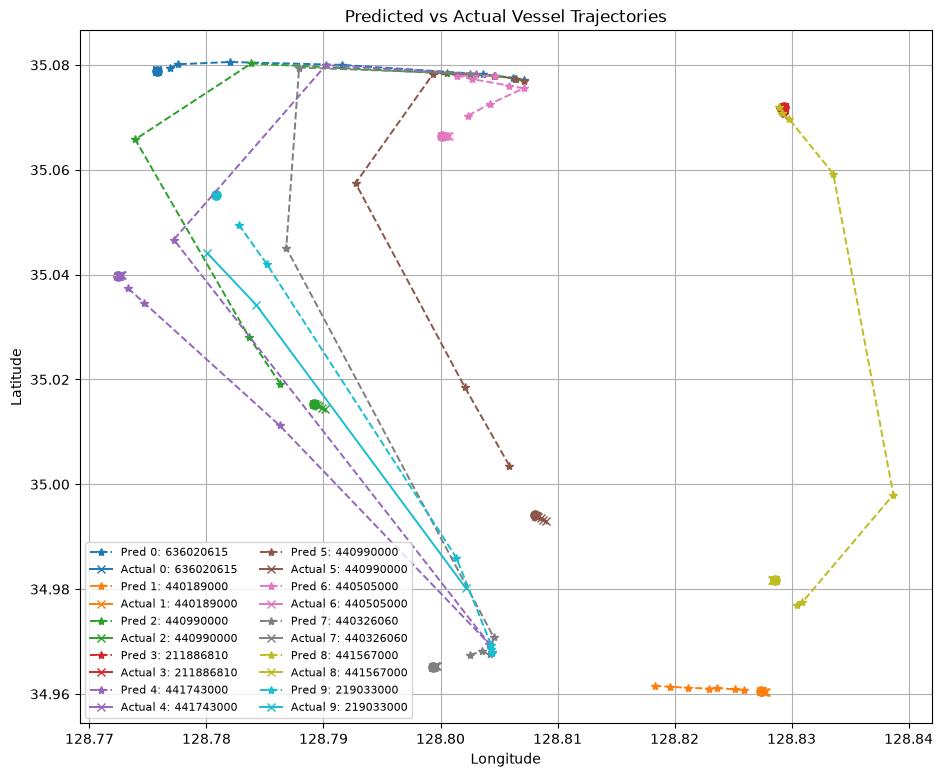

In [33]:
# 21. ?? ?? 10?: ?? ??? vs ?? ??? ???

plt.figure(figsize=(11, 9))
colors = plt.cm.tab10(np.linspace(0, 1, max(len(selected_trajectory_paths), 1)))

for i, item in enumerate(selected_trajectory_paths):
    color = colors[i]
    pred_path = item["pred_path"]
    actual_path = item["actual_path"]

    plt.scatter(item["start_lon"], item["start_lat"], color=color, marker="o", s=45)

    plt.plot(
        pred_path["lon"], pred_path["lat"],
        color=color, linestyle="--", marker="*", linewidth=1.4,
        label=f"Pred {i}: {item['MMSI']}"
    )

    if len(actual_path) > 0:
        plt.plot(
            actual_path["lon"], actual_path["lat"],
            color=color, linestyle="-", marker="x", linewidth=1.4,
            label=f"Actual {i}: {item['MMSI']}"
        )

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Predicted vs Actual Vessel Trajectories")
plt.grid(True)
plt.legend(fontsize=8, ncol=2)

ax = plt.gca()
ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.ticklabel_format(style="plain", axis="both")

plt.show()

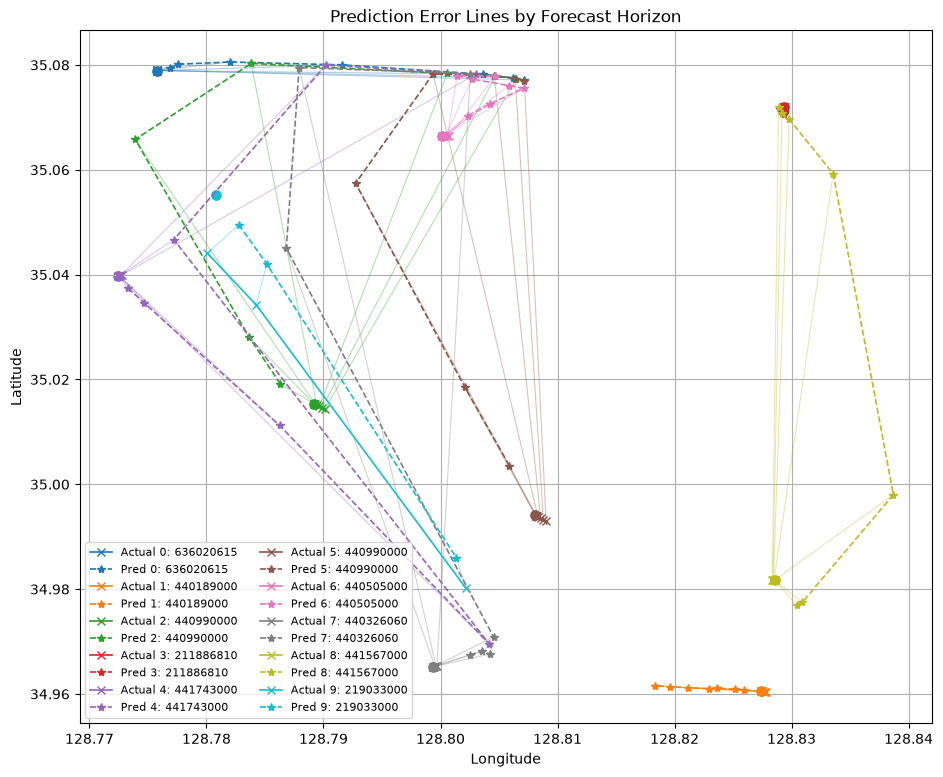

In [34]:
# 22. ?? ?? 10?: ??-?? ??? ???

plt.figure(figsize=(11, 9))
colors = plt.cm.tab10(np.linspace(0, 1, max(len(selected_trajectory_paths), 1)))

for i, item in enumerate(selected_trajectory_paths):
    color = colors[i]
    pred_path = item["pred_path"]
    actual_path = item["actual_path"]

    merged = pred_path.merge(
        actual_path,
        on="forecast_minutes",
        suffixes=("_pred", "_actual")
    )

    plt.scatter(item["start_lon"], item["start_lat"], color=color, marker="o", s=45)

    plt.plot(
        merged["lon_actual"], merged["lat_actual"],
        color=color, linestyle="-", marker="x", linewidth=1.2,
        label=f"Actual {i}: {item['MMSI']}"
    )
    plt.plot(
        merged["lon_pred"], merged["lat_pred"],
        color=color, linestyle="--", marker="*", linewidth=1.2,
        label=f"Pred {i}: {item['MMSI']}"
    )

    for _, row in merged.iterrows():
        plt.plot(
            [row["lon_actual"], row["lon_pred"]],
            [row["lat_actual"], row["lat_pred"]],
            color=color,
            alpha=0.35,
            linewidth=0.8
        )

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Prediction Error Lines by Forecast Horizon")
plt.grid(True)
plt.legend(fontsize=8, ncol=2)

ax = plt.gca()
ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.ticklabel_format(style="plain", axis="both")

plt.show()

,forecast_minutes,valid_count,mean_error_km,median_error_km,rmse_km,p90_error_km,max_error_km,mean_error_nm,median_error_nm
0,5,694,0.157093,0.071608,0.261648,0.401366,2.244903,0.084823,0.038665
1,10,694,0.281767,0.098352,0.532042,0.778824,3.977443,0.152142,0.053106
2,30,692,0.835120,0.155593,1.896179,3.483469,10.869863,0.450929,0.084014
3,60,689,1.341548,0.234989,2.819891,5.663768,12.826305,0.724378,0.126884
4,120,683,2.116652,0.381771,4.082551,7.810106,13.348309,1.142901,0.206140
5,180,681,2.456637,0.510786,4.546966,10.575862,13.281826,1.326478,0.275802
6,240,670,2.531985,0.600113,4.603652,10.688292,13.147976,1.367163,0.324035


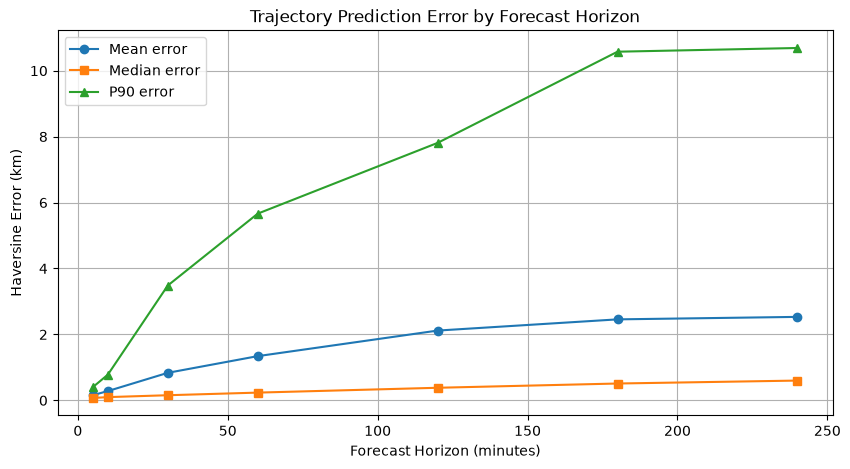

In [35]:
# 23. ?? ??: Horizon? ?? ?? ?? ??
# ?? ??? ??? ? ???? ????.

if len(trajectory_results_df) == 0:
    raise ValueError("trajectory_results_df? ?? ????. 19? ?? ?? ?? ?? ?????.")

trajectory_summary_df = (
    trajectory_results_df
    .groupby("forecast_minutes")
    .agg(
        valid_count=("error_km", "count"),
        mean_error_km=("error_km", "mean"),
        median_error_km=("error_km", "median"),
        rmse_km=("error_km", lambda x: np.sqrt(np.mean(np.square(x)))),
        p90_error_km=("error_km", lambda x: np.percentile(x, 90)),
        max_error_km=("error_km", "max"),
        mean_error_nm=("error_nm", "mean"),
        median_error_nm=("error_nm", "median")
    )
    .reset_index()
)

display(trajectory_summary_df)

plt.figure(figsize=(10, 5))
plt.plot(
    trajectory_summary_df["forecast_minutes"],
    trajectory_summary_df["mean_error_km"],
    marker="o",
    label="Mean error"
)
plt.plot(
    trajectory_summary_df["forecast_minutes"],
    trajectory_summary_df["median_error_km"],
    marker="s",
    label="Median error"
)
plt.plot(
    trajectory_summary_df["forecast_minutes"],
    trajectory_summary_df["p90_error_km"],
    marker="^",
    label="P90 error"
)

plt.xlabel("Forecast Horizon (minutes)")
plt.ylabel("Haversine Error (km)")
plt.title("Trajectory Prediction Error by Forecast Horizon")
plt.grid(True)
plt.legend()
plt.show()